In [1]:
from langgraph.graph import StateGraph,START ,END
from langchain_openai import ChatOpenAI 
from typing  import TypedDict
import os
from dotenv import load_dotenv

In [2]:
load_dotenv 

<function dotenv.main.load_dotenv(dotenv_path: Union[str, ForwardRef('os.PathLike[str]'), NoneType] = None, stream: Optional[IO[str]] = None, verbose: bool = False, override: bool = False, interpolate: bool = True, encoding: Optional[str] = 'utf-8') -> bool>

In [3]:
llm = ChatOpenAI(
    base_url="https://openrouter.ai/api/v1",
    #api_key=os.getenv("OPENROUTER_API_KEY"),
    api_key="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",
    model="meta-llama/llama-3.3-70b-instruct:free"
)

In [4]:
# create  a state 
class LLMState(TypedDict):
    title : str 
    outline : str 
    content : str 


In [5]:
def gen_outline(state : LLMState)->LLMState:

    # extract the question from state 

    title  = state['title']

    #form a prompt 
    prompt = f'Generate a detailed outline for a blog  on the topic - {title}'

    # ask the que to the LLm 

    outline  = llm.invoke(prompt).content

    #update the answer in the state 

    state['outline']= outline 

    return state

In [6]:
def gen_blog(state: LLMState)->LLMState:
        # extract the question from state 

    title  = state['title']
    outline =state['outline']

    #form a prompt 
    prompt = f'Write  detailed blog on the title {title} using the following outline \n {outline}'

    # ask the que to the LLm 

    content  = llm.invoke(prompt).content

    #update the answer in the state 

    state['content']= content 

    return state


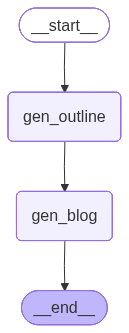

In [8]:
# create graph 
graph = StateGraph(LLMState)

# add node 

graph.add_node('gen_outline' , gen_outline)
graph.add_node('gen_blog' , gen_blog)

# add edge 

graph.add_edge(START, 'gen_outline')
graph.add_edge('gen_outline','gen_blog')
graph.add_edge('gen_blog',END)

#compile 

graph.compile()



In [9]:
workflow =graph.compile()

In [ ]:
# execute 
intial_state = {'title' : 'Rise of Ai in India ' }

final_state = workflow.invoke(intial_state)

print(final_state)

{'title': 'Rise of Ai in India ', 'outline': 'Here is a detailed outline for a blog on the topic "Rise of AI in India":\n\n**Title:** "The Rise of AI in India: Opportunities, Challenges, and Future Prospects"\n\n**Introduction**\n\n* Brief overview of Artificial Intelligence (AI) and its growing importance globally\n* Introduction to the Indian context: why AI is crucial for India\'s growth and development\n* Thesis statement: India is poised to become a significant player in the global AI landscape, with tremendous opportunities and challenges ahead.\n\n**Section 1: Current State of AI in India**\n\n* Overview of the current AI landscape in India:\n\t+ Key sectors where AI is being adopted (e.g., healthcare, finance, education, manufacturing)\n\t+ Major AI-powered initiatives and projects in India (e.g., Digital India, Make in India, Smart Cities)\n\t+ Government initiatives and policies supporting AI development (e.g., NITI Aayog\'s AI strategy, AI Task Force)\n* Statistics and data 

In [25]:
print(final_state['content'])

**The Rise of AI in India: Opportunities, Challenges, and Future Prospects**

Artificial Intelligence (AI) has emerged as a transformative technology, revolutionizing industries and revolutionizing the way we live and work. As the world becomes increasingly digital, AI is poised to play a vital role in shaping the future of economies, societies, and individuals. In this blog, we will explore the rise of AI in India, a country with a large and growing economy, a vibrant startup ecosystem, and a highly skilled workforce. We will examine the current state of AI in India, the drivers of its growth, the opportunities and applications of AI, the challenges and limitations, and the future prospects of this technology.

**Current State of AI in India**

India has made significant strides in adopting AI in various sectors, including healthcare, finance, education, and manufacturing. The government has launched several initiatives to promote AI development, such as the Digital India program, Mak